Loading the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
# Beautiful plot style (for all plots)
sns.set(style="whitegrid", palette="viridis", font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
import sys 
import os

sys.path.append(os.path.abspath("../src"))

from data_loader import load_data

df = load_data("../data/insurance_data.csv")
print(f"\n ✅ Data loaded successfully")
print(f" Shape: {df.shape[0]:,} rows and {df.shape[1]} columns")

print("\n === First 5 Rows ===")
display(df.head())
print("\n=== COLUMN NAMES ===")
print(df.columns.tolist())

print("\n=== DATA TYPES SUMMARY ===")
print(df.dtypes.value_counts())

c:\Users\bezaw\OneDrive\Desktop\Git Projects\Insurance-risk-analytics\src\data_loader.py:9: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, sep = '|')


 Successfuly loaded data from ../data/insurance_data.csv

 ✅ Data loaded successfully
 Shape: 1,000,098 rows and 52 columns

 === First 5 Rows ===


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0



=== COLUMN NAMES ===
['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium', 'TotalClaims']

=== DATA TYPES SUMMARY ===
str        35
float64    11
int64       4
bool        1
object      1
Name: count, dtype: int64


Data quality and structure

In [3]:
print(' === Missing Values')
missing = df.isnull().sum()
print(missing[missing > 0])

print("\n === Data Types ===")
print(df.dtypes)

print("\n=== Numeric Columns Summary ===")
print(df.describe(include= 'number') [['TotalPremium', 'TotalClaims','CalculatedPremiumPerTerm', 'SumInsured' ]])

# Fix date 

if not pd.api.types.is_datetime64_any_dtype(df['TransactionMonth']):
    df['TransactionMonth'] = pd.to_datetime(df['TransactionMonth'] + '-01', errors='coerce')
    print("\n✅ TransactionMonth converted to datetime!")

print("\n✅ Data quality check complete!")

 === Missing Values
Bank                        145961
AccountType                  40232
MaritalStatus                 8259
Gender                        9536
mmcode                         552
VehicleType                    552
make                           552
Model                          552
Cylinders                      552
cubiccapacity                  552
kilowatts                      552
bodytype                       552
NumberOfDoors                  552
VehicleIntroDate               552
CustomValueEstimate         779642
CapitalOutstanding               2
NewVehicle                  153295
WrittenOff                  641901
Rebuilt                     641901
Converted                   641901
CrossBorder                 999400
NumberOfVehiclesInFleet    1000098
dtype: int64

 === Data Types ===
UnderwrittenCoverID           int64
PolicyID                      int64
TransactionMonth                str
IsVATRegistered                bool
Citizenship                     

Column,Missing,What it means for the business
NumberOfVehiclesInFleet,"1,000,098 (100%)",Almost nobody has a fleet → this column is useless for analysis (we’ll drop it later)
CrossBorder,"999,400 (~99.9%)",Almost all policies are South African → not useful
CustomValueEstimate,"779,642 (~78%)",Most cars don’t have a custom valuation → we’ll impute with median in Task 4
WrittenOff / Rebuilt / Converted,"~641,901 (~64%)","These are rare events (total loss, rebuilt car) → useful flag but mostly “No”"
CapitalOutstanding,only 2,Almost perfect → keep it
"Car details (mmcode, make, Model, etc.)",552,Very small % → probably new policies without full car info

=== UNIVARIATE ANALYSIS STARTED ===


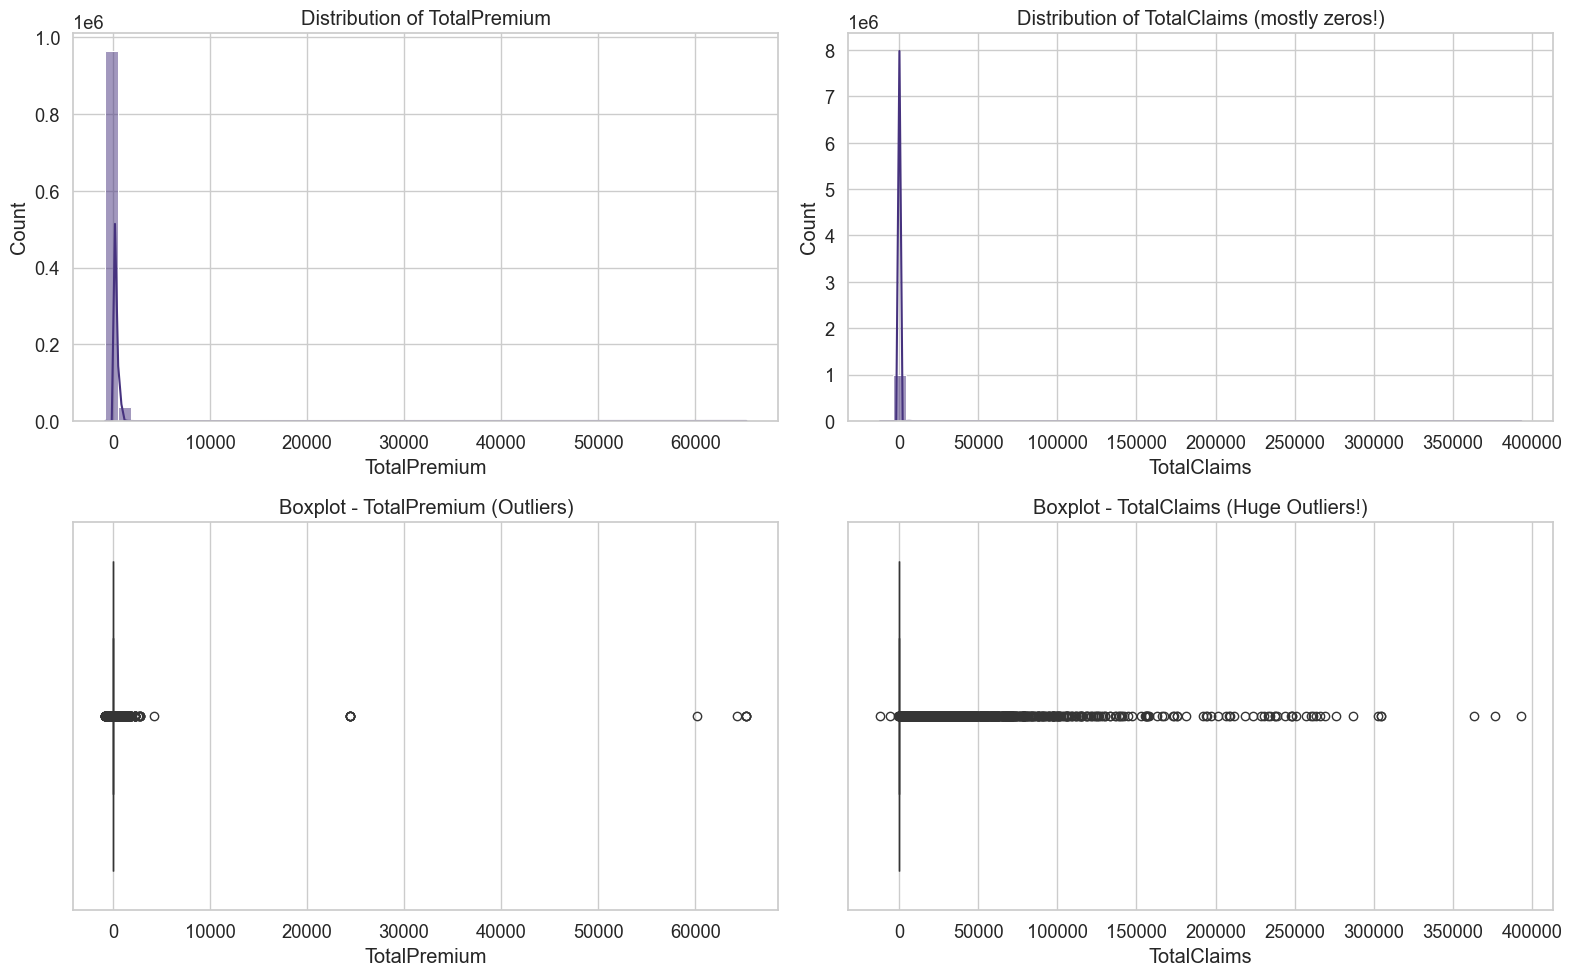

C:\Users\bezaw\AppData\Local\Temp\ipykernel_3800\737854972.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', palette='viridis')


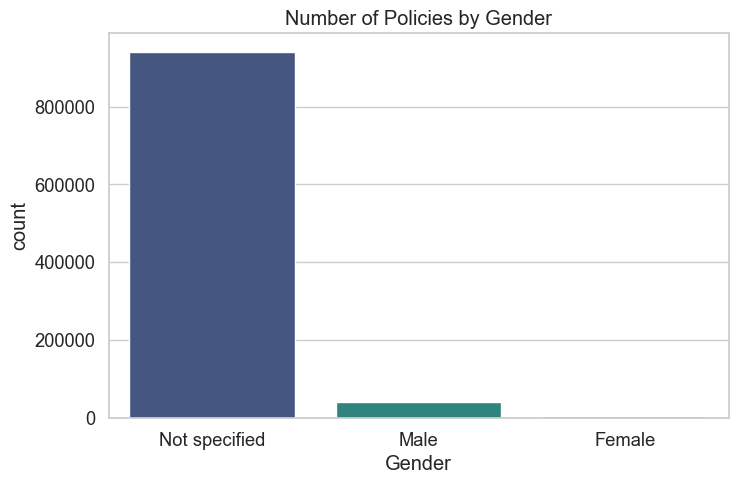

✅ Two beautiful plots saved in reports/figures/
   → univariate_numerical.png
   → gender_distribution.png


In [ ]:
# ====================== CELL 3: UNIVARIATE ANALYSIS (Distributions) ======================
import os
os.makedirs('reports/figures', exist_ok=True)
print("=== UNIVARIATE ANALYSIS STARTED ===")

# 1. Numerical variables - Histograms + Boxplot (shows outliers)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(df['TotalPremium'], bins=50, kde=True, ax=axes[0,0])
axes[0,0].set_title('Distribution of TotalPremium')

sns.histplot(df['TotalClaims'], bins=50, kde=True, ax=axes[0,1])
axes[0,1].set_title('Distribution of TotalClaims (mostly zeros!)')

sns.boxplot(x=df['TotalPremium'], ax=axes[1,0])
axes[1,0].set_title('Boxplot - TotalPremium (Outliers)')

sns.boxplot(x=df['TotalClaims'], ax=axes[1,1])
axes[1,1].set_title('Boxplot - TotalClaims (Huge Outliers!)')

plt.tight_layout()
plt.savefig('reports/figures/univariate_numerical.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Categorical example - Gender (very important for hypothesis later)
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Gender', palette='viridis')
plt.title('Number of Policies by Gender')
plt.savefig('reports/figures/gender_distribution.png', dpi=300)
plt.show()

print("✅ Two plots saved in reports/figures/")
print("   → univariate_numerical.png")
print("   → gender_distribution.png")